In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
#from OceanDataStore import OceanDataCatalog
from region import Region


import xarray as xr
import matplotlib.pyplot as plt
from glob import glob

In [3]:
fsose = '/gws/nopw/j04/sid/workspaces/jcocks/data/SOSE/Adelie_138E_150E/Adelie*.nc'
sose = xr.open_mfdataset(glob(fsose))

In [4]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',variable_names=['zos'])

NameError: name 'OceanDataCatalog' is not defined

In [5]:
sla = SLA(deg=0.25).da

In [6]:
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]
t1 = sose.time[0]
t2 = sla.time[-1]


In [ ]:
# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to time
zos = nemo.zos.where(mask,drop=True)
# make monthly
zos = zos.resample({'time_counter':'MS'}).mean()
# relative anomaly wrt common time period
zos = zos - zos.sel(time_counter=slice(t1,t2)).mean('time_counter')

In [11]:
zos.load()

<xarray.DataArray 'zos' (time_counter: 576, y: 28, x: 142)> Size: 9MB
array([[[-1.30617619e-03, -3.84807587e-04,  7.20024109e-04, ...,
          2.49568224e-02,  2.45563984e-02,  2.41961479e-02],
        [-3.91006470e-04,  4.37736511e-04,  1.43337250e-03, ...,
          2.48590708e-02,  2.45083570e-02,  2.41997242e-02],
        [ 5.67674637e-04,  1.27160549e-03,  2.13396549e-03, ...,
          2.44156122e-02,  2.41643190e-02,  2.39410400e-02],
        ...,
        [-3.22461128e-04, -4.50253487e-04, -6.21080399e-04, ...,
          1.91605091e-03,  1.77979469e-03,  1.89495087e-03],
        [-9.84668732e-04, -1.15168095e-03, -1.38223171e-03, ...,
          2.57611275e-04, -4.29153442e-05, -1.53422356e-04],
        [-1.63888931e-03, -1.82282925e-03, -2.08389759e-03, ...,
         -2.03168392e-03, -2.49683857e-03, -2.83360481e-03]],

       [[-1.40957832e-02, -1.33540630e-02, -1.25511885e-02, ...,
          6.32774830e-03,  6.02149963e-03,  5.72133064e-03],
        [-1.32719278e-02, -1.25455856e-02, -1.18013620e-02, ...,
          6.77096844e-03,  6.56461716e-03,  6.35468960e-03],
        [-1.22946501e-02, -1.16035938e-02, -1.09580755e-02, ...,
          6.81555271e-03,  6.73770905e-03,  6.64532185e-03],
...
         -5.42253256e-02, -5.74308634e-02, -6.05524778e-02],
        [-5.28180599e-02, -5.35136461e-02, -5.45927286e-02, ...,
         -4.52526808e-02, -4.88225222e-02, -5.29966354e-02],
        [-5.11671305e-02, -5.18974066e-02, -5.30292988e-02, ...,
         -3.46986055e-02, -3.82194519e-02, -4.29869890e-02]],

       [[-5.89808226e-02, -5.93644381e-02, -6.03070259e-02, ...,
         -3.14304829e-02, -3.13848257e-02, -3.13891172e-02],
        [-5.81159592e-02, -5.84232807e-02, -5.91722727e-02, ...,
         -3.12408209e-02, -3.13686132e-02, -3.15151215e-02],
        [-5.72332144e-02, -5.74676991e-02, -5.80128431e-02, ...,
         -3.05858850e-02, -3.08538675e-02, -3.11203003e-02],
        ...,
        [-3.26972008e-02, -3.29946280e-02, -3.31981182e-02, ...,
         -2.78376341e-02, -3.18886042e-02, -3.59923840e-02],
        [-3.12660933e-02, -3.20390463e-02, -3.27066183e-02, ...,
         -2.12174654e-02, -2.59978771e-02, -3.14083099e-02],
        [-2.95726061e-02, -3.07934284e-02, -3.19850445e-02, ...,
         -1.39614344e-02, -1.91413164e-02, -2.53849030e-02]]],
      shape=(576, 28, 142), dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 5kB 1976-01-01 ... 2023-12-01
  * y             (y) int64 224B 978 979 980 981 982 ... 1002 1003 1004 1005
  * x             (x) int64 1kB 782 783 784 785 786 787 ... 919 920 921 922 923
    nav_lat       (y, x) float64 32kB -65.94 -65.94 -65.94 ... -65.01 -65.01
    nav_lon       (y, x) float64 32kB 138.2 138.2 138.3 ... 149.7 149.8 149.9
Attributes:
    standard_name:       sea_surface_height_above_geoid
    long_name:           Sea Surface Height Above Geoid
    units:               m
    online_operation:    average
    interval_operation:  450 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 450 s)

In [7]:
# prepare SLA
# cropto region
sla = Region('AC',extent).crop_da(sla)
# take new mean
sla = sla - sla.sel(time=slice(t1,t2)).mean('time')
# convert to m
sla = sla / 100

In [8]:
rho_w = 1028.5
rho_ice = 910
rho_snow = 330

sload = (sose.SIheff * rho_ice) + (sose.SIhsnow * rho_snow)

sload = sload / rho_w

# correct SSH for loading
etan = (sose.ETAN + sload)

# prepare SOSE
etan = etan.resample({'time':'MS'}).mean()
etan = etan - etan.sel(time=slice(t1,t2)).mean('time')


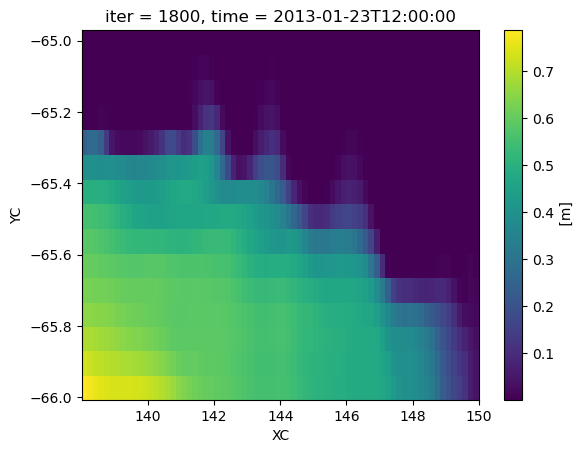

In [14]:
sload.isel(time=4).plot()

In [9]:
etan.load()

<xarray.DataArray (time: 132, YC: 15, XC: 72)> Size: 570kB
array([[[-0.15945125, -0.15631902, -0.15350664, ..., -0.13806379,
         -0.14027512, -0.14156485],
        [-0.15143311, -0.1488818 , -0.14667082, ..., -0.12868345,
         -0.1317569 , -0.1339606 ],
        [-0.14335132, -0.14146328, -0.13993514, ..., -0.1155194 ,
         -0.1190232 , -0.12223661],
        ...,
        [-0.05741537, -0.05318069, -0.05202007, ...,  0.04058409,
          0.0388819 ,  0.03431022],
        [-0.04013729, -0.03640378, -0.03593075, ...,  0.0567255 ,
          0.05457592,  0.04953909],
        [-0.02836406, -0.02539015, -0.02570605, ...,  0.07259893,
          0.07034934,  0.06515086]],

       [[-0.15649247, -0.15382981, -0.15246809, ..., -0.14161932,
         -0.14443159, -0.14640403],
        [-0.15093744, -0.14867795, -0.1476425 , ..., -0.12787616,
         -0.13115072, -0.13371837],
        [-0.1464231 , -0.14489341, -0.14419162, ..., -0.11230648,
         -0.11570227, -0.11873496],
...
        [ 0.05964518,  0.06006896,  0.05793607, ...,  0.02819633,
          0.02856362,  0.02928865],
        [ 0.05688703,  0.05599117,  0.05304193, ...,  0.0311265 ,
          0.02931821,  0.02812648],
        [ 0.04999256,  0.04953921,  0.04734838, ...,  0.03901327,
          0.03527009,  0.0312016 ]],

       [[ 0.06958663,  0.07152212,  0.07448781, ...,  0.04103065,
          0.04143417,  0.04253066],
        [ 0.07002318,  0.07135594,  0.07362175, ...,  0.03872025,
          0.03902829,  0.04011106],
        [ 0.06803596,  0.0689435 ,  0.07079458, ...,  0.03681719,
          0.03717005,  0.03831768],
        ...,
        [ 0.06112289,  0.06242228,  0.06709588, ...,  0.03553641,
          0.03220224,  0.0309186 ],
        [ 0.05920887,  0.06082487,  0.06454611, ...,  0.03821218,
          0.03308809,  0.02970564],
        [ 0.0555805 ,  0.05639112,  0.05853271, ...,  0.04412603,
          0.0375886 ,  0.03118539]]], shape=(132, 15, 72), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * XC       (XC) float64 576B 138.1 138.2 138.4 138.6 ... 149.6 149.8 149.9
    rA       (YC, XC) float64 9kB 5.692e+07 5.692e+07 ... 6.13e+07 6.13e+07
    Depth    (YC, XC) float64 9kB 900.0 950.0 950.0 ... 3.32e+03 3.32e+03
Attributes:
    standard_name:  ETAN
    long_name:      Surface Height Anomaly
    units:          m

In [15]:
etanav = etan.mean(['XC','YC'])
zosav = zos.mean(['x','y'])
slaav = sla.mean(['latitude','longitude'])

Text(0, 0.5, 'sla (cm)')

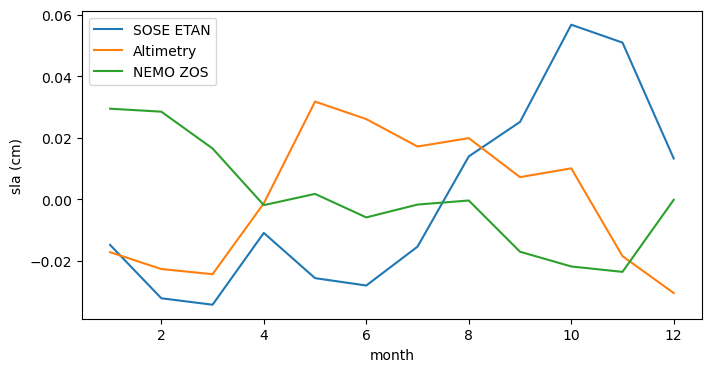

In [19]:
# compare climatologies
fig,ax = plt.subplots(figsize=(8,4))
soseclim=etanav.sel(time=slice(t1,t2)).groupby('time.month').mean()
alticlim=slaav.sel(time=slice(t1,t2)).groupby('time.month').mean()
nemoclim=zosav.sel(time_counter=slice(t1,t2)).groupby('time_counter.month').mean()

ax.plot(soseclim.month,soseclim,label='SOSE ETAN')
ax.plot(alticlim.month,alticlim,label='Altimetry')
ax.plot(nemoclim.month,nemoclim,label='NEMO ZOS')

ax.legend()
ax.set_xlabel('month')
ax.set_ylabel('sla (cm)')


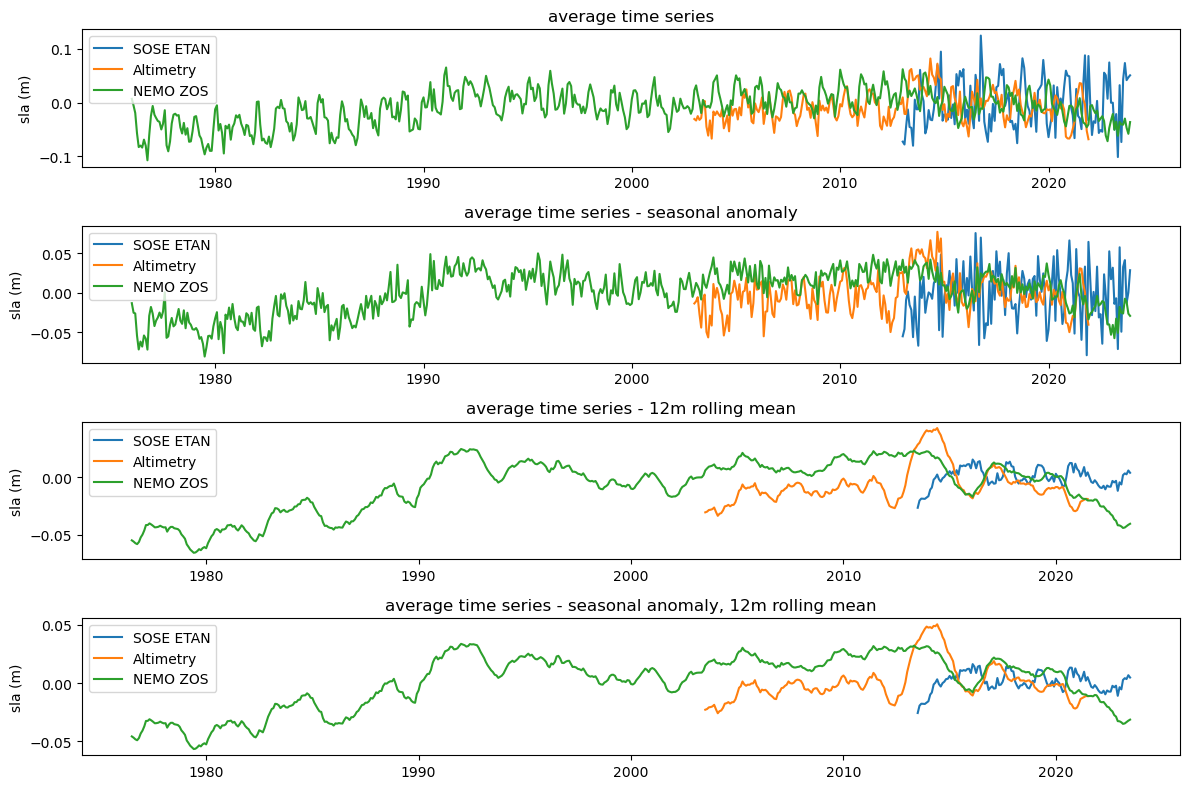

In [17]:
# compare time series
fig,axs = plt.subplots(4,1,figsize=(12,8))

# 1 - straightforward timeseries
ax=axs[0]
ax.plot(etan.time,etanav,label='SOSE ETAN')
ax.plot(sla.time,slaav,label='Altimetry')
ax.plot(zos.time_counter,zosav,label='NEMO ZOS')
ax.set_title('average time series')

ax.legend()
ax.set_ylabel('sla (m)')


# 2 - seasonal anomaly
ax=axs[1]
ax.plot(etan.time,etanav.groupby('time.month') - soseclim,label='SOSE ETAN')
ax.plot(sla.time,slaav.groupby('time.month') - alticlim,label='Altimetry')
ax.plot(zos.time_counter,zosav.groupby('time_counter.month') - nemoclim,label='NEMO ZOS')
ax.set_title('average time series - seasonal anomaly')

ax.legend()
ax.set_ylabel('sla (m)')

# 3 - rolling timeseries
ax=axs[2]
ax.plot(etan.time,etanav.rolling({'time':12},center=True).mean(),label='SOSE ETAN')
ax.plot(sla.time,slaav.rolling({'time':12},center=True).mean(),label='Altimetry')
ax.plot(zos.time_counter,zosav.rolling({'time_counter':12},center=True).mean(),label='NEMO ZOS')
ax.set_title('average time series - 12m rolling mean')

ax.legend()
ax.set_ylabel('sla (m)')

# 4 - rolling timeseries
ax=axs[3]
ax.plot(etan.time,(etanav.groupby('time.month') - soseclim).rolling({'time':12},center=True).mean(),label='SOSE ETAN')
ax.plot(sla.time,(slaav.groupby('time.month') - alticlim).rolling({'time':12},center=True).mean(),label='Altimetry')
ax.plot(zos.time_counter,(zosav.groupby('time_counter.month') - nemoclim).rolling({'time_counter':12},center=True).mean(),label='NEMO ZOS')
ax.set_title('average time series - seasonal anomaly, 12m rolling mean')

ax.legend()
ax.set_ylabel('sla (m)')

plt.tight_layout()